In [51]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [52]:
df = pd.read_csv('data/Titanic-Dataset.csv')
print("Shape:", df.shape)
df.head()


Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 1. Keşifsel Veri Analizi (EDA)

In [53]:
# Genel bilgi
print("=== Eksik Değerler ===")
print(df.isnull().sum())
print()
print("=== Survived Dağılımı ===")
print(df['Survived'].value_counts())


=== Eksik Değerler ===
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

=== Survived Dağılımı ===
Survived
0    549
1    342
Name: count, dtype: int64


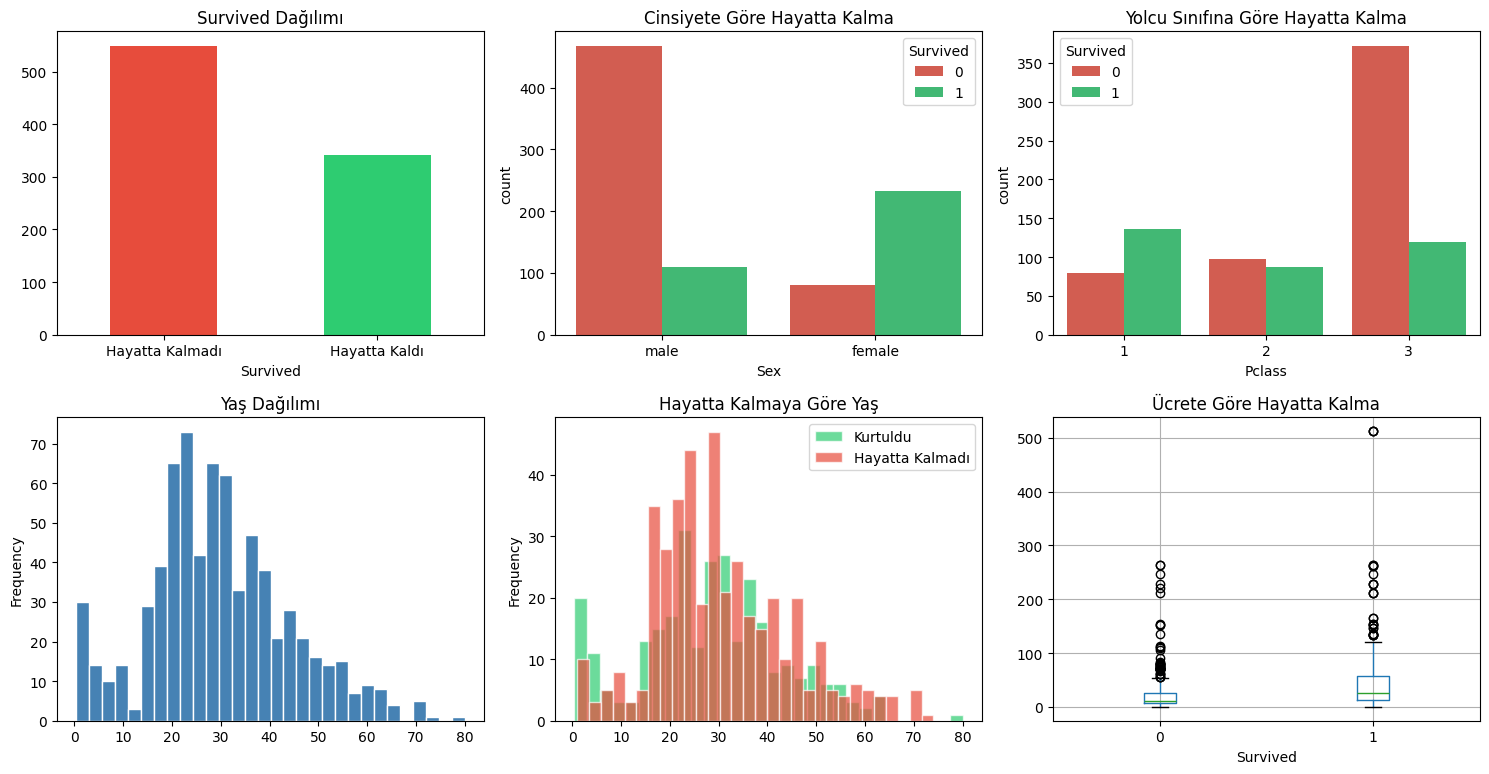

In [54]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# 1. Survived dağılımı
df['Survived'].value_counts().plot(kind='bar', ax=axes[0,0], color=['#e74c3c','#2ecc71'])
axes[0,0].set_title('Survived Dağılımı')
axes[0,0].set_xticklabels(['Hayatta Kalmadı', 'Hayatta Kaldı'], rotation=0)

# 2. Cinsiyete göre hayatta kalma
sns.countplot(data=df, x='Sex', hue='Survived', ax=axes[0,1], palette=['#e74c3c','#2ecc71'])
axes[0,1].set_title('Cinsiyete Göre Hayatta Kalma')

# 3. Sınıfa göre hayatta kalma
sns.countplot(data=df, x='Pclass', hue='Survived', ax=axes[0,2], palette=['#e74c3c','#2ecc71'])
axes[0,2].set_title('Yolcu Sınıfına Göre Hayatta Kalma')

# 4. Yaş dağılımı
df['Age'].dropna().plot(kind='hist', ax=axes[1,0], bins=30, color='steelblue', edgecolor='white')
axes[1,0].set_title('Yaş Dağılımı')

# 5. Hayatta kalanlarda yaş
df[df['Survived']==1]['Age'].dropna().plot(kind='hist', ax=axes[1,1], bins=30, color='#2ecc71', edgecolor='white', alpha=0.7, label='Kurtuldu')
df[df['Survived']==0]['Age'].dropna().plot(kind='hist', ax=axes[1,1], bins=30, color='#e74c3c', edgecolor='white', alpha=0.7, label='Hayatta Kalmadı')
axes[1,1].set_title('Hayatta Kalmaya Göre Yaş')
axes[1,1].legend()

# 6. Bilet ücretine göre hayatta kalma
df.boxplot(column='Fare', by='Survived', ax=axes[1,2])
axes[1,2].set_title('Ücrete Göre Hayatta Kalma')

plt.suptitle('')
plt.tight_layout()
plt.show()


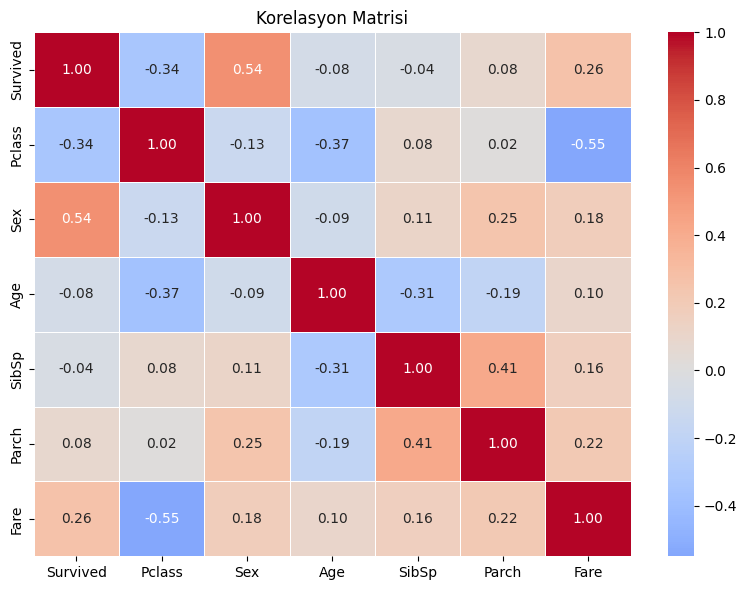

In [55]:
corr = df[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']].copy()
corr['Sex'] = corr['Sex'].map({'male': 0, 'female': 1})

plt.figure(figsize=(8, 6))
sns.heatmap(corr.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Korelasyon Matrisi')
plt.tight_layout()
plt.show()


## 2. Preprocessing

### 2.1 Gereksiz Sütunları At

In [56]:
# PassengerId: sadece index, bilgi taşımıyor
# Name: kategorik, çok fazla unique değer, model için anlamsız
# Ticket: düzensiz format, anlamlı pattern çıkarmak zor
# Cabin: %77 eksik, kullanılamaz

drop_cols = ['PassengerId', 'Name', 'Ticket', 'Cabin']
df = df.drop(columns=drop_cols)

print("Shape:", df.shape)
df.head()


Shape: (891, 8)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


### 2.2 Eksik Değerleri Doldur

In [57]:
# Age → median ile doldur (outlier'lara karşı mean'den daha dayanıklı)
df['Age'] = df['Age'].fillna(df['Age'].median())

# Embarked → mode ile doldur (sadece 2 eksik, en sık değer mantıklı)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

print("Eksik değerler:")
print(df.isnull().sum())


Eksik değerler:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


### 2.3 Outlier Analizi

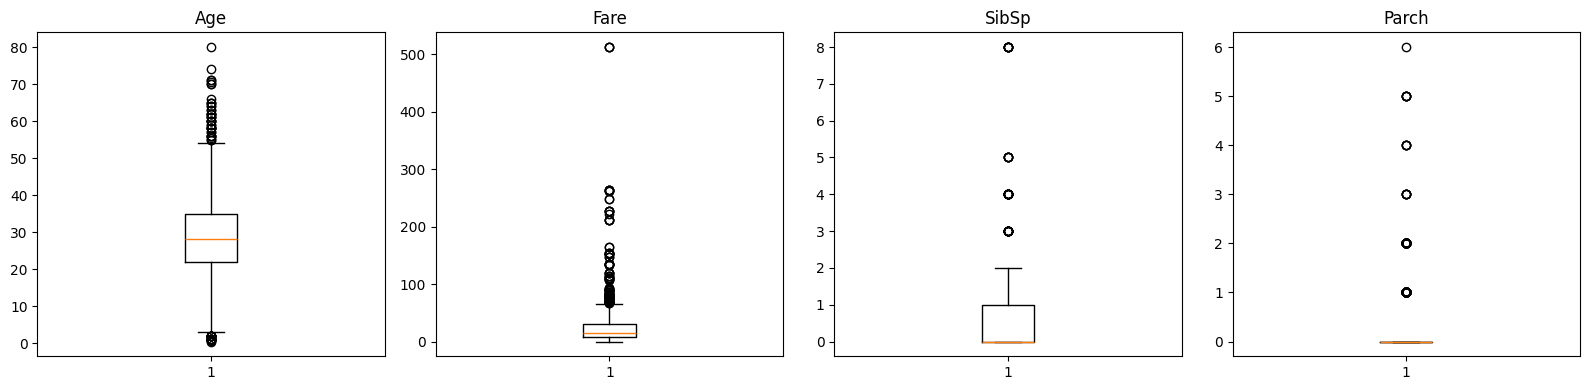

=== IQR Outlier Sayıları ===
Age: 66 outlier
Fare: 116 outlier
SibSp: 46 outlier
Parch: 213 outlier


In [58]:
num_cols = ['Age', 'Fare', 'SibSp', 'Parch']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

# IQR ile outlier sayısı
print("=== IQR Outlier Sayıları ===")
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} outlier")


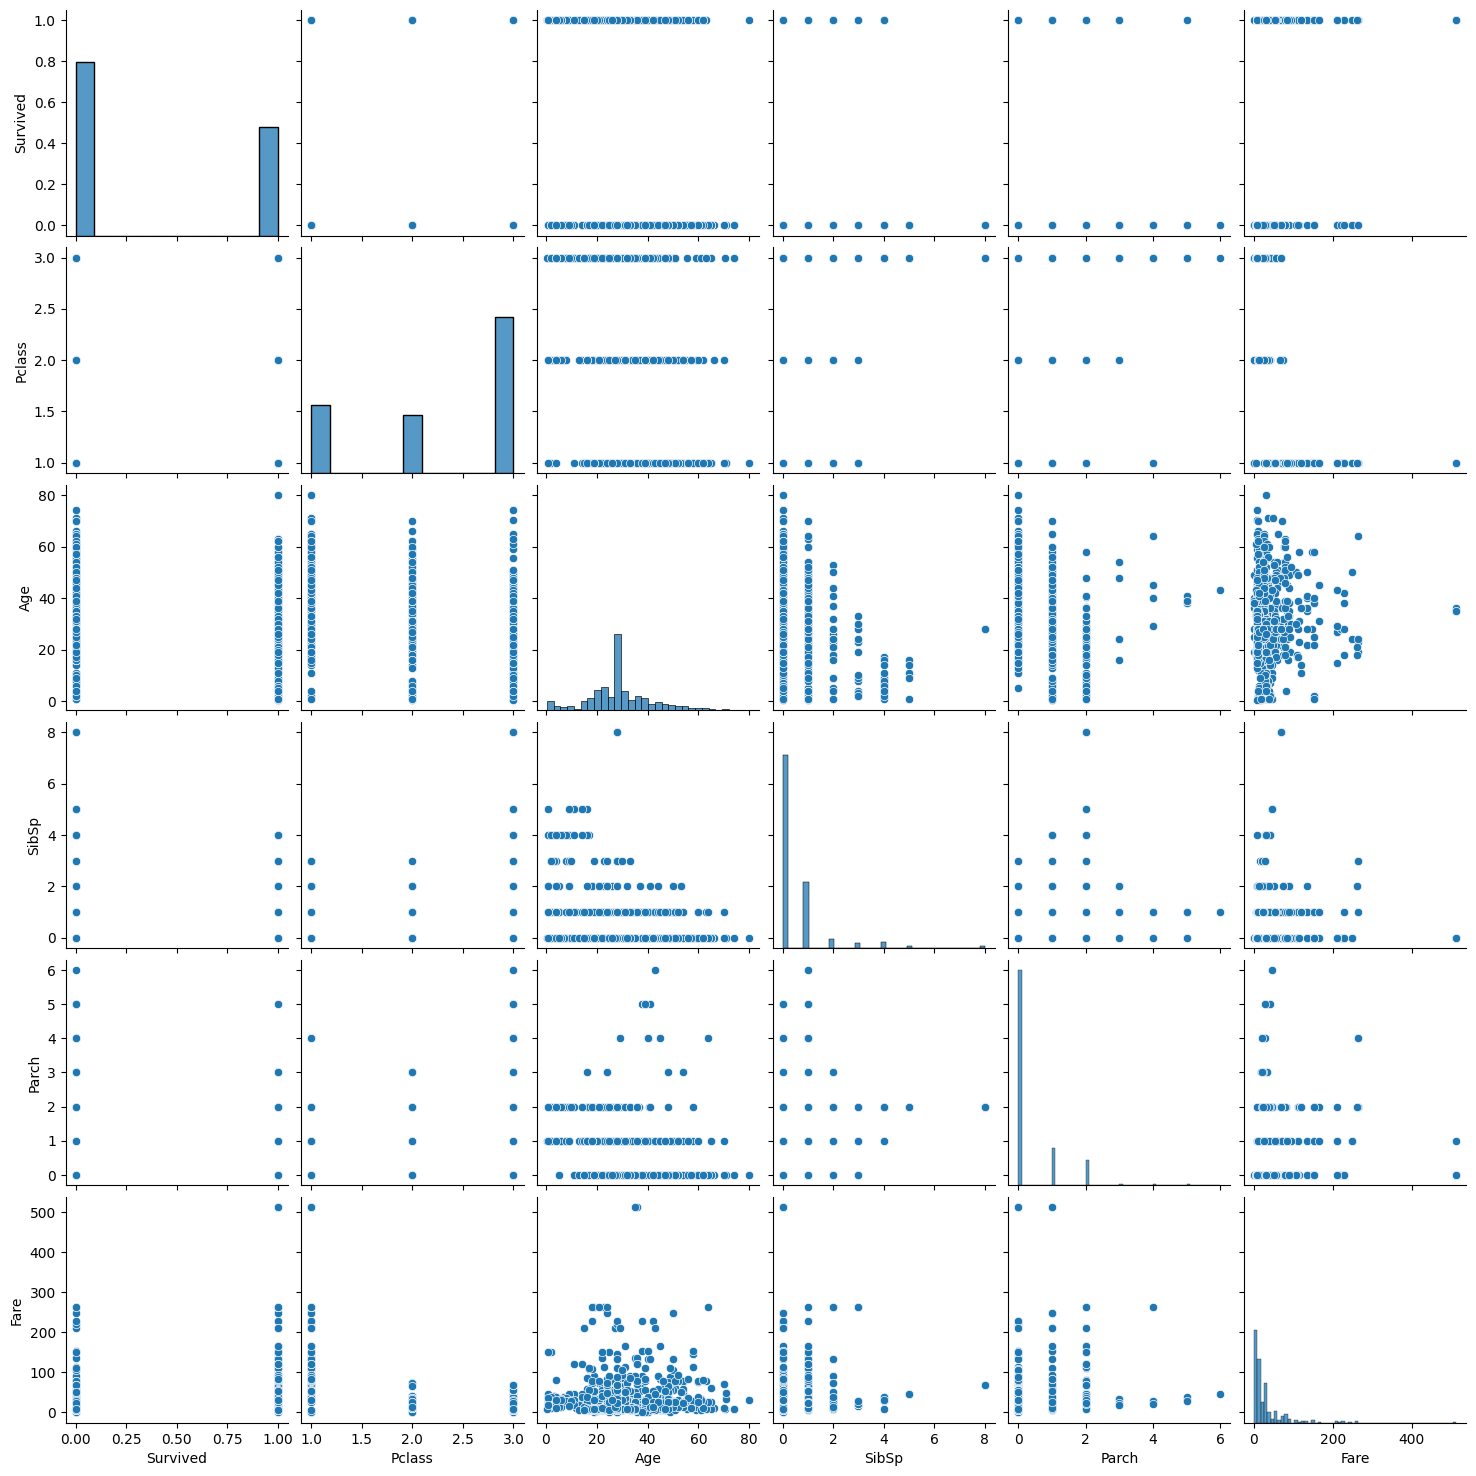

In [59]:
sns.pairplot(df)
plt.show()


### 2.4 Encoding

In [60]:
# Sex → binary encoding (male: 0, female: 1)
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# Embarked → one-hot encoding (S, C, Q)
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

print(df.columns.tolist())
df.head()


['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,False,True
1,1,1,1,38.0,1,0,71.2833,False,False
2,1,3,1,26.0,0,0,7.9250,False,True
3,1,1,1,35.0,1,0,53.1000,False,True
4,0,3,0,35.0,0,0,8.0500,False,True


### 2.5 Feature Engineering (Fare → log1p)

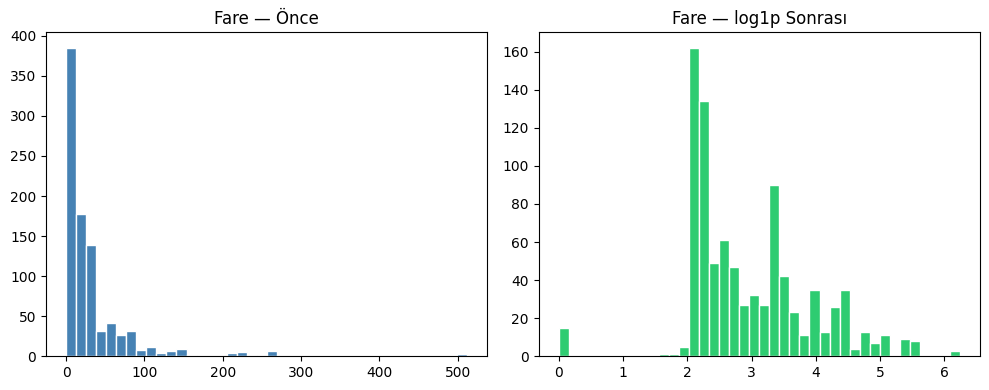

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(df['Fare'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Fare — Önce')

df['Fare'] = np.log1p(df['Fare'])

axes[1].hist(df['Fare'], bins=40, color='#2ecc71', edgecolor='white')
axes[1].set_title('Fare — log1p Sonrası')

plt.tight_layout()
plt.show()


### 2.6 Scaling

In [62]:
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['Survived'])
y = df['Survived']

scale_cols = ['Age', 'Fare', 'SibSp', 'Parch']

scaler = StandardScaler()
X[scale_cols] = scaler.fit_transform(X[scale_cols])

print("Feature shape:", X.shape)
print("Dtypes:\n", X.dtypes)

X = X.astype(float).values
y = y.values


Feature shape: (891, 8)
Dtypes:
 Pclass          int64
Sex             int64
Age           float64
SibSp         float64
Parch         float64
Fare          float64
Embarked_Q       bool
Embarked_S       bool
dtype: object


In [63]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [64]:
# in multiclass classification y type should be long because of cross entropy loss function
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test  = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

In [65]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

(torch.Size([712, 8]),
 torch.Size([712, 1]),
 torch.Size([179, 8]),
 torch.Size([179, 1]))

In [66]:
from torch import nn
class TitanicClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(8, 20),   # input: 8 features
            nn.ReLU(),          # activation

            nn.Linear(20, 20),  # hidden layer
            nn.ReLU(),          # activation

            nn.Linear(20, 1)    # output: 2 classes → logits
        )

    def forward(self, x):
        return self.linear_layer_stack(x)

In [67]:
model=TitanicClassifier()
loss_fn=nn.BCEWithLogitsLoss()
optimizer=torch.optim.Adam(params=model.parameters(),lr=0.01)

In [68]:
from torchmetrics.classification import Accuracy
accuracy = Accuracy(task='binary')

In [69]:
torch.manual_seed(42)
epochs = 100

for epoch in range(epochs):
    # --- EĞİTİM ADIMI ---
    model.train()
    y_logits = model(X_train)
    y_pred   = torch.round(torch.sigmoid(y_logits))
    loss     = loss_fn(y_logits, y_train)
    acc      = accuracy(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # --- DEĞERLENDİRME ADIMI ---
    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test)
        test_pred   = torch.round(torch.sigmoid(test_logits))
        test_loss   = loss_fn(test_logits, y_test)
        test_acc    = accuracy(test_pred, y_test)

    if epoch % 10 == 0:
        print(f"Epoch: {epoch:3d} | Loss: {loss:.4f} | Acc: {acc:.4f} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")


Epoch:   0 | Loss: 0.6833 | Acc: 0.6166 | Test Loss: 0.6693 | Test Acc: 0.6145
Epoch:  10 | Loss: 0.5487 | Acc: 0.7317 | Test Loss: 0.5566 | Test Acc: 0.7430
Epoch:  20 | Loss: 0.4512 | Acc: 0.8006 | Test Loss: 0.4818 | Test Acc: 0.7709
Epoch:  30 | Loss: 0.4208 | Acc: 0.8048 | Test Loss: 0.4432 | Test Acc: 0.8268
Epoch:  40 | Loss: 0.4082 | Acc: 0.8230 | Test Loss: 0.4345 | Test Acc: 0.8268
Epoch:  50 | Loss: 0.4000 | Acc: 0.8230 | Test Loss: 0.4345 | Test Acc: 0.8324
Epoch:  60 | Loss: 0.3925 | Acc: 0.8301 | Test Loss: 0.4353 | Test Acc: 0.8212
Epoch:  70 | Loss: 0.3841 | Acc: 0.8357 | Test Loss: 0.4392 | Test Acc: 0.8324
Epoch:  80 | Loss: 0.3744 | Acc: 0.8427 | Test Loss: 0.4468 | Test Acc: 0.8156
Epoch:  90 | Loss: 0.3623 | Acc: 0.8511 | Test Loss: 0.4593 | Test Acc: 0.8045


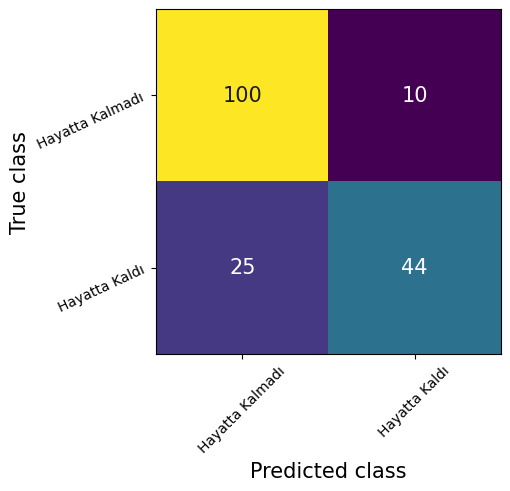

In [70]:
from torchmetrics.classification import ConfusionMatrix

cm = ConfusionMatrix(task='binary')
matrix = cm(test_pred, y_test)

fig, ax = cm.plot(labels=['Hayatta Kalmadı', 'Hayatta Kaldı'])
plt.show()


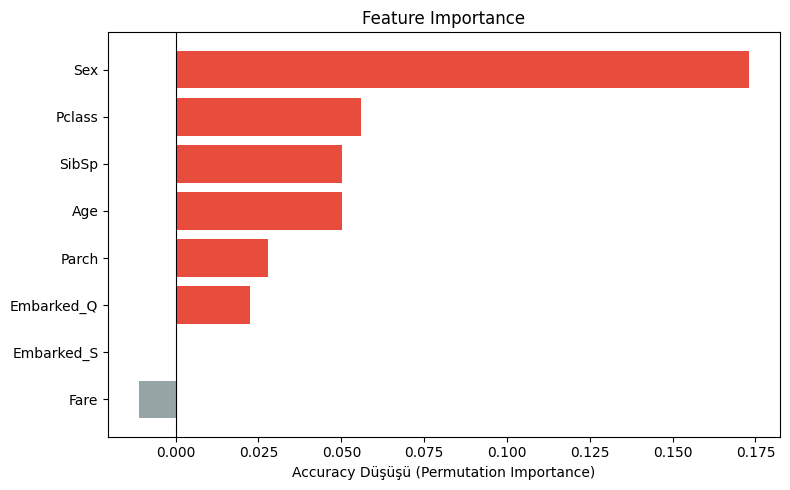

In [71]:
feature_names = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']

model.eval()
importances = []

with torch.inference_mode():
    base_logits = model(X_test)
    base_pred   = torch.round(torch.sigmoid(base_logits))
    base_acc    = accuracy(base_pred, y_test).item()

    for i in range(X_test.shape[1]):
        # Her feature için 10 kez karıştır, ortalamasını al (daha stabil)
        accs = []
        for _ in range(10):
            torch.manual_seed(42 + i)
            X_permuted = X_test.clone()
            X_permuted[:, i] = X_test[:, i][torch.randperm(X_test.shape[0])]
            perm_pred = torch.round(torch.sigmoid(model(X_permuted)))
            accs.append(accuracy(perm_pred, y_test).item())
        importances.append(base_acc - np.mean(accs))

# Grafik
plt.figure(figsize=(8, 5))
sorted_idx = np.argsort(importances)
colors = ['#e74c3c' if v > 0 else '#95a5a6' for v in np.array(importances)[sorted_idx]]
plt.barh([feature_names[i] for i in sorted_idx], np.array(importances)[sorted_idx], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Accuracy Düşüşü (Permutation Importance)')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()


In [72]:
# ── Ham veri girişi (orijinal format) ─────────────────────────────────────────
pclass   = 1          # Yolcu sınıfı     : 1, 2, 3
sex      = 'female'   # Cinsiyet         : 'male' / 'female'
age      = 29.0       # Yaş
sibsp    = 0          # Kardeş/eş sayısı
parch    = 0          # Ebeveyn/çocuk sayısı
fare     = 75.0       # Bilet ücreti (£)
embarked = 'C'        # Biniş limanı     : 'S'=Southampton, 'C'=Cherbourg, 'Q'=Queenstown

# ── Otomatik preprocessing ────────────────────────────────────────────────────
passenger_df = pd.DataFrame([{
    'Pclass':     pclass,
    'Sex':        1 if sex == 'female' else 0,
    'Age':        age,
    'SibSp':      sibsp,
    'Parch':      parch,
    'Fare':       np.log1p(fare),
    'Embarked_Q': 1 if embarked == 'Q' else 0,
    'Embarked_S': 1 if embarked == 'S' else 0,
}])

passenger_df[['Age', 'Fare', 'SibSp', 'Parch']] = scaler.transform(
    passenger_df[['Age', 'Fare', 'SibSp', 'Parch']]
)

passenger_tensor = torch.tensor(passenger_df.values.astype(float), dtype=torch.float32)

model.eval()
with torch.inference_mode():
    logit = model(passenger_tensor)
    prob  = torch.sigmoid(logit).item()
    pred  = int(prob >= 0.5)

print(f"── Yolcu Bilgileri ──────────────────")
print(f"  Sınıf    : {pclass}. sınıf")
print(f"  Cinsiyet : {sex}")
print(f"  Yaş      : {age}")
print(f"  SibSp    : {sibsp}")
print(f"  Parch    : {parch}")
print(f"  Ücret    : £{fare}")
print(f"  Liman    : {embarked}")
print(f"────────────────────────────────────")
print(f"  Hayatta kalma olasılığı : %{prob*100:.1f}")
print(f"  Tahmin : {'✓ Hayatta Kaldı' if pred == 1 else '✗ Hayatta Kalmadı'}")


── Yolcu Bilgileri ──────────────────
  Sınıf    : 1. sınıf
  Cinsiyet : female
  Yaş      : 29.0
  SibSp    : 0
  Parch    : 0
  Ücret    : £75.0
  Liman    : C
────────────────────────────────────
  Hayatta kalma olasılığı : %98.4
  Tahmin : ✓ Hayatta Kaldı


In [73]:
from pathlib import Path

In [74]:
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "titanic_model.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

torch.save(obj=model.state_dict(), f=MODEL_SAVE_PATH)

In [75]:
model.state_dict()

OrderedDict([('linear_layer_stack.0.weight',
              tensor([[-0.2876, -0.1989, -0.2339, -0.1809,  0.0520, -0.0858, -0.2667,  0.0346],
                      [-0.0307,  0.0430, -0.1774,  0.3106, -0.0537, -0.0013, -0.2237,  0.1617],
                      [ 0.2893, -0.4826,  0.5181, -0.8197, -0.7768,  0.2605, -0.3709,  0.5795],
                      [ 0.2185,  0.3137, -0.3292, -0.5099, -0.3268,  0.3176,  0.0049, -0.2819],
                      [ 0.4656,  0.0589, -0.0778,  0.2538, -0.0477,  0.0865,  0.2732,  0.1456],
                      [ 0.0413,  0.3680, -0.2354, -0.1740,  0.2151,  0.0204,  0.3495,  0.1118],
                      [-0.3527, -0.3128, -0.2311,  0.0896,  0.1180, -0.1820, -0.1322, -0.1789],
                      [-0.3684,  0.3044,  0.0793,  0.8285,  0.6615, -0.1459,  0.4665, -0.1307],
                      [-0.1084, -0.1145,  0.1426, -0.0210, -0.3503, -0.4041,  0.0700,  0.4959],
                      [-0.4333,  0.7977,  0.1435,  0.1679, -0.0751,  0.0095,  0.6771,  0.03

In [76]:
import joblib
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']